<a href="https://colab.research.google.com/github/salmaelafifi/ML-55-1251/blob/main/Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dataset

1. We use the Bank Marketing Dataset from the UCI Machine Learning Repository.
Source: https://archive.ics.uci.edu/ml/datasets/bank+marketing

2. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. Originally designed for supervised learning, but we will ignore the label initially

Important Decision:

Even though the dataset contains subscribed (whether the client subscribed to a term deposit), we do not use it to train the clustering model.
We may, however, use it later for interpretation only.

    # bank client data:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

## task 1

### Requirements

The goal of this lab is to **explore the bank dataset, prepare it for clustering, and apply K-Means**.  
Follow these steps carefully and write down your observations.  

### **Exploratory Data Analysis (EDA)** (understanding the dataset and its characteristics)

For each feature, you should:

- Identify **numeric vs categorical features**  
- Check **distributions** of numeric features (min, max, mean, std, skewness)  
- Check **counts of categories** for categorical features  
- Identify **missing or unknown values** and decide how to handle them  
- Look for **correlations** between numeric features  
- Identify **outliers** that may affect clustering  

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
bank_df = pd.read_csv("bank-additional-full.csv", sep=';')
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
bank_df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Numeric VS Categorical Features

In [3]:
numeric_features = bank_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = bank_df.select_dtypes(include=['object']).columns.tolist()

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric Features:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


# Numeric Distributions

In [4]:
numeric_stats_summary=bank_df[numeric_features].describe().T
numeric_stats_summary['skewness']=bank_df.skew(numeric_only=True)
numeric_stats_summary


,count,mean,std,min,25%,50%,75%,max,skewness
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000,0.784697
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000,3.263141
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000,4.762507
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000,-4.922190
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000,3.832042
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400,-0.724096
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767,-0.230888
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900,0.303180
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045,-0.709188
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100,-1.044262


# Categorical Counts

In [31]:
for col in categorical_features:
    categorical_df = bank_df[col].value_counts(dropna=False).reset_index()
    categorical_df.columns = [col, 'count']
    display(categorical_df)

,job,count
0,admin.,10422
1,blue-collar,9254
2,technician,6743
3,services,3969
4,management,2924
5,retired,1720
6,entrepreneur,1456
7,self-employed,1421
8,housemaid,1060
9,unemployed,1014


,marital,count
0,married,24928
1,single,11568
2,divorced,4612
3,unknown,80


,education,count
0,university.degree,12168
1,high.school,9515
2,basic.9y,6045
3,professional.course,5243
4,basic.4y,4176
5,basic.6y,2292
6,unknown,1731
7,illiterate,18


,default,count
0,no,32588
1,unknown,8597
2,yes,3


,housing,count
0,yes,21576
1,no,18622
2,unknown,990


...

,contact,count
0,cellular,26144
1,telephone,15044


,month,count
0,may,13769
1,jul,7174
2,aug,6178
3,jun,5318
4,nov,4101
5,apr,2632
6,oct,718
7,sep,570
8,mar,546
9,dec,182


,day_of_week,count
0,thu,8623
1,mon,8514
2,wed,8134
3,tue,8090
4,fri,7827


,poutcome,count
0,nonexistent,35563
1,failure,4252
2,success,1373


,y,count
0,no,36548
1,yes,4640


# Missing and Unknown Values

In [6]:
sum_null_per_column=bank_df.isnull().sum()
sum_null_per_column

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [49]:
sum_unknown_per_column = (bank_df == "unknown").sum()
print("====Unknown Count====")
print(sum_unknown_per_column)
print("====Percentage Unknown====")
print(sum_unknown_per_column / len(bank_df) * 100)


====Unknown Count====
age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64
====Percentage Unknown====
age                0.000000
job                0.801204
marital            0.194231
education          4.202680
default           20.872584
housing            2.403613
loan               2.403613
contact            0.000000
month              0.000000
day_of_week        0.000000
duration           0.000000
campaign           0.000000
pdays              0.000000
previous           0.000000
poutcome           0.000000
emp.var.rate       0.000000
cons.pr

In [72]:
unknown_rows = bank_df[bank_df.isin(['unknown']).any(axis=1)]
display(unknown_rows)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
10,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
15,54,retired,married,basic.9y,unknown,yes,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41118,34,technician,married,unknown,no,yes,no,cellular,nov,tue,...,2,999,2,failure,-1.1,94.767,-50.8,1.046,4963.6,no
41120,60,admin.,married,unknown,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.046,4963.6,no
41122,34,technician,married,unknown,no,no,no,cellular,nov,tue,...,3,999,0,nonexistent,-1.1,94.767,-50.8,1.046,4963.6,yes
41135,54,technician,married,unknown,no,yes,no,cellular,nov,thu,...,1,999,1,failure,-1.1,94.767,-50.8,1.041,4963.6,no


In [64]:
bank_df_clean = bank_df.copy()
# For any feature with 'unknown'
features_with_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']

for col in features_with_unknown:
    bank_df_clean[col + '_unknown_flag'] = (bank_df_clean[col] == 'unknown').astype(int)

numeric_cols = bank_df_clean.select_dtypes(include=['int64', 'float64']).columns

for col in features_with_unknown:
    flag = col + '_unknown_flag'
    corr_with_numeric = bank_df_clean[numeric_cols].corrwith(bank_df_clean[flag])
    print(f"\n{col} unknown correlation with numeric features:")
    print(corr_with_numeric.sort_values(ascending=False))


job unknown correlation with numeric features:
job_unknown_flag          1.000000
education_unknown_flag    0.158978
default_unknown_flag      0.055701
marital_unknown_flag      0.051704
age                       0.047773
cons.conf.idx             0.033103
cons.price.idx            0.022246
euribor3m                 0.016982
emp.var.rate              0.015789
nr.employed               0.007334
campaign                  0.002625
previous                 -0.003345
housing_unknown_flag     -0.005213
loan_unknown_flag        -0.005213
duration                 -0.006450
pdays                    -0.011419
dtype: float64

marital unknown correlation with numeric features:
marital_unknown_flag      1.000000
job_unknown_flag          0.051704
education_unknown_flag    0.015494
campaign                  0.009873
duration                  0.009263
previous                  0.009095
age                       0.001062
cons.conf.idx            -0.003025
loan_unknown_flag        -0.003323
housing_un

In [65]:
for col in features_with_unknown:
    flag = col + '_unknown_flag'
    print(f"\n{col} unknown probability by category:")
    for cat_col in categorical_features:
        if cat_col != col:
            ct = pd.crosstab(bank_df_clean[cat_col], bank_df_clean[flag], normalize='index')
            print(f"\n{cat_col} vs {flag} probability:\n", ct)


job unknown probability by category:

marital vs job_unknown_flag probability:
 job_unknown_flag         0         1
marital                             
divorced          0.997181  0.002819
married           0.990613  0.009387
single            0.993603  0.006397
unknown           0.887500  0.112500

education vs job_unknown_flag probability:
 job_unknown_flag            0         1
education                              
basic.4y             0.987548  0.012452
basic.6y             0.990401  0.009599
basic.9y             0.994872  0.005128
high.school          0.996111  0.003889
illiterate           1.000000  0.000000
professional.course  0.997711  0.002289
university.degree    0.996302  0.003698
unknown              0.924321  0.075679

default vs job_unknown_flag probability:
 job_unknown_flag         0         1
default                             
no                0.994538  0.005462
unknown           0.982319  0.017681
yes               1.000000  0.000000

poutcome vs job_unknown

In [69]:
housing_unknown = bank_df_clean['housing'] == 'unknown'
loan_unknown = bank_df_clean['loan'] == 'unknown'
both_unknown = housing_unknown & loan_unknown
print("Rows with BOTH housing and loan unknown:", both_unknown.sum())
rows_both_unknown = bank_df_clean[both_unknown]
display(rows_both_unknown)

Rows with BOTH housing and loan unknown: 990


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.conf.idx,euribor3m,nr.employed,y,job_unknown_flag,marital_unknown_flag,education_unknown_flag,default_unknown_flag,housing_unknown_flag,loan_unknown_flag
29,55,unknown,married,university.degree,unknown,unknown,unknown,telephone,may,mon,...,-36.4,4.857,5191.0,no,1,0,0,1,1,1
81,51,blue-collar,married,basic.4y,unknown,unknown,unknown,telephone,may,mon,...,-36.4,4.857,5191.0,no,0,0,0,1,1,1
261,27,blue-collar,single,basic.6y,no,unknown,unknown,telephone,may,mon,...,-36.4,4.857,5191.0,no,0,0,0,0,1,1
385,59,management,married,basic.4y,unknown,unknown,unknown,telephone,may,tue,...,-36.4,4.857,5191.0,no,0,0,0,1,1,1
401,48,services,married,high.school,unknown,unknown,unknown,telephone,may,tue,...,-36.4,4.857,5191.0,no,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40990,31,admin.,single,university.degree,no,unknown,unknown,cellular,oct,tue,...,-49.5,1.008,4963.6,yes,0,0,0,0,1,1
41014,31,technician,single,professional.course,no,unknown,unknown,cellular,oct,thu,...,-49.5,1.025,4963.6,yes,0,0,0,0,1,1
41015,34,admin.,divorced,university.degree,no,unknown,unknown,cellular,oct,thu,...,-49.5,1.025,4963.6,no,0,0,0,0,1,1
41029,46,management,married,university.degree,no,unknown,unknown,cellular,oct,mon,...,-49.5,1.032,4963.6,no,0,0,0,0,1,1


**Notes on Unknown Values in Columns**

*   Job : 0.801204% of data in this coloumn is unknown, data is considered MCAR. Can be imputed using Frequency Imputation(less than 5%)
*   Martial : 0.194231% of data in this coloumn is unknown, data is considered MCAR. Can be imputed using Frequency Imputation(less than 5%)
*   Education : 4.202680% of data in this coloumn is unknown, data is considered MCAR. Can be imputed using Frequency Imputation(less than 5%) or can consider linking its imputation to job and age column
*   Default : 20.872584% of data in this coloumn is unknown, data is considered MCAR. Will not impute but keep the category "Unknown" since 20.872584% is very high and want to preserve data integrity
*   Housing : 2.403613% of data in this coloumn is unknown, the unknown data is also always unknown when the loan data is also unknown. This make the feature MCAR to the other features but NMAR to loan feature meaning that they must be imputed together
*   Loan : 2.403613% of data in this coloumn is unknown, the unknown data is also always unknown when the housing data is also unknown. This make the feature MCAR to the other features but NMAR to housing feature meaning that they must be imputed together.

For loan and housing will impute with the most frequent combination







In [75]:


mode_impute_cols = ['job', 'marital', 'education']

for col in mode_impute_cols:
    mode_value = bank_df_clean[col].mode()[0]
    unknown_count = (bank_df_clean[col] == 'unknown').sum()

    print(f"{col.upper()}:")
    print(f"  Mode           : {mode_value}")
    print(f"  Unknown count  : {unknown_count}")
    print()

JOB:
  Mode           : admin.
  Unknown count  : 330

MARITAL:
  Mode           : married
  Unknown count  : 80

EDUCATION:
  Mode           : university.degree
  Unknown count  : 1731



In [86]:
bank_df_imputed=bank_df.copy()
mode_impute_cols = ['job', 'marital']
for col in mode_impute_cols:
    mode_value = bank_df_imputed[col].mode()[0]
    bank_df_imputed[col] = bank_df_imputed[col].replace('unknown', mode_value)

In [87]:
# Replace 'unknown' in Education using mode of Education within the same Job
bank_df_imputed['education'] = bank_df_imputed.groupby('job')['education'].transform(
    lambda x: x.where(x != 'unknown', x.mode()[0])
)

In [88]:
most_common_hl = bank_df_imputed.groupby(['housing', 'loan']).size().idxmax()
print("Most Common Housing and Loan Combo")
print(most_common_hl)
# Fill rows where both are unknown with the most common combination
mask = (bank_df_imputed['housing'] == 'unknown') & (bank_df_imputed['loan'] == 'unknown')
bank_df_imputed.loc[mask, ['housing', 'loan']] = most_common_hl

Most Common Housing and Loan Combo
('yes', 'no')


In [89]:
for col in ['job', 'marital', 'education', 'housing', 'loan']:
    print(f"{col} unknown count after imputation:", (bank_df_imputed[col] == 'unknown').sum())

job unknown count after imputation: 0
marital unknown count after imputation: 0
education unknown count after imputation: 0
housing unknown count after imputation: 0
loan unknown count after imputation: 0


# Correlations

In [32]:
corr_matrix = bank_df.corr(numeric_only=True)
corr_matrix

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


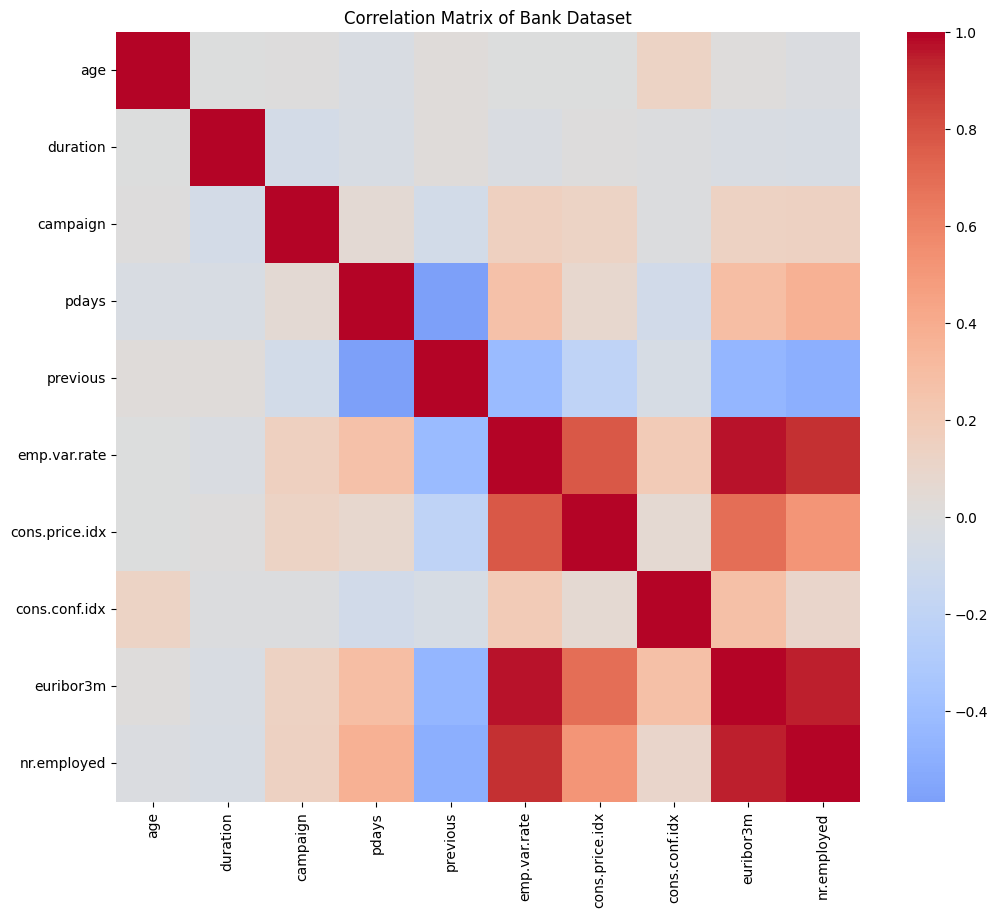

In [33]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Bank Dataset")
plt.show()

In [37]:
threshold = 0.5

corr_abs = corr_matrix.abs()
upper_tri = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

strong_pairs = (
    upper_tri
    .stack()
    .reset_index()
)

strong_pairs.columns = ['feature_1', 'feature_2', 'correlation']

strong_pairs = strong_pairs[strong_pairs['correlation'] > threshold]

strong_pairs

,feature_1,feature_2,correlation
24,pdays,previous,0.587514
34,previous,nr.employed,0.501333
35,emp.var.rate,cons.price.idx,0.775334
37,emp.var.rate,euribor3m,0.972245
38,emp.var.rate,nr.employed,0.906970
40,cons.price.idx,euribor3m,0.688230
41,cons.price.idx,nr.employed,0.522034
44,euribor3m,nr.employed,0.945154


# Outliers

In [44]:
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)]
    return outliers, lower, upper

In [45]:
outlier_summary = {}
for col in numeric_features:
    outliers, lower, upper = detect_outliers(bank_df[col])
    count = len(outliers)
    percent = count / len(bank_df) * 100

    outlier_summary[col] = {'Count': count, 'Percentage': percent, 'Outliers Below': lower, 'Outliers Above': upper}

outlier_df = pd.DataFrame(outlier_summary).T
display(outlier_df)

,Count,Percentage,Outliers Below,Outliers Above
age,469.0,1.138681,9.5000,69.5000
duration,2963.0,7.193843,-223.5000,644.5000
campaign,2406.0,5.841507,-2.0000,6.0000
pdays,1515.0,3.678256,999.0000,999.0000
previous,5625.0,13.656890,0.0000,0.0000
emp.var.rate,0.0,0.000000,-6.6000,6.2000
cons.price.idx,0.0,0.000000,91.6965,95.3725
cons.conf.idx,447.0,1.085268,-52.1500,-26.9500
euribor3m,0.0,0.000000,-4.0815,10.3865
nr.employed,0.0,0.000000,4905.6000,5421.6000


### **Data Preparation**

Before applying K-Means:

- Drop irrelevant or target columns
- Encode categorical features into numeric format
- Scale numeric features so all are comparable for distance calculations  
- Check that the final dataset has **no missing values** and **all features are numeric**  

Notes on Column Dropping

Will drop target column and duration. Duration will be dropped since it only highly affects target and as shown from correlation matrix it is not highly correlated with any other numeric feature.

In [90]:
bank_kmeans = bank_df_imputed.copy()

drop_cols = ['y', 'duration']
bank_kmeans.drop(columns=drop_cols, inplace=True)
bank_kmeans.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0


In [99]:
from sklearn.preprocessing import LabelEncoder

# Make a copy so original df stays intact
bank_kmeans_encoded = bank_kmeans.copy()

# --- Label Encoding for ordinal feature ---
le = LabelEncoder()
bank_kmeans_encoded['education'] = le.fit_transform(bank_kmeans_encoded['education'])

# --- One-Hot Encoding for nominal features ---
nominal_features = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

bank_kmeans_encoded = pd.get_dummies(bank_kmeans_encoded, columns=nominal_features, drop_first=False)
bool_cols = bank_kmeans_encoded.select_dtypes(include='bool').columns
bank_kmeans_encoded[bool_cols] = bank_kmeans_encoded[bool_cols].astype(int)

bank_kmeans_encoded.head()


,age,education,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,0,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
1,57,3,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
2,37,3,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
3,40,1,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
4,56,3,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0


In [100]:
from sklearn.preprocessing import StandardScaler

bank_kmeans_scaled=bank_kmeans_encoded.copy()

numeric_features = ['age', 'campaign', 'pdays', 'previous',
                    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                    'euribor3m', 'nr.employed']

scaler = StandardScaler()
bank_kmeans_scaled[numeric_features] = scaler.fit_transform(bank_kmeans_scaled[numeric_features])
bank_kmeans_scaled.head()

,age,education,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,1.533034,0,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,...,0,0,0,1,0,0,0,0,1,0
1,1.628993,3,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,...,0,0,0,1,0,0,0,0,1,0
2,-0.290186,3,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,...,0,0,0,1,0,0,0,0,1,0
3,-0.002309,1,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,...,0,0,0,1,0,0,0,0,1,0
4,1.533034,3,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,...,0,0,0,1,0,0,0,0,1,0


In [101]:
missing_count = bank_kmeans_scaled.isnull().sum()
print("Missing values per column:")
print(missing_count)

Missing values per column:
age                     0
education               0
campaign                0
pdays                   0
previous                0
emp.var.rate            0
cons.price.idx          0
cons.conf.idx           0
euribor3m               0
nr.employed             0
job_admin.              0
job_blue-collar         0
job_entrepreneur        0
job_housemaid           0
job_management          0
job_retired             0
job_self-employed       0
job_services            0
job_student             0
job_technician          0
job_unemployed          0
marital_divorced        0
marital_married         0
marital_single          0
default_no              0
default_unknown         0
default_yes             0
housing_no              0
housing_yes             0
loan_no                 0
loan_yes                0
contact_cellular        0
contact_telephone       0
month_apr               0
month_aug               0
month_dec               0
month_jul               0
month_jun  

In [102]:

non_numeric = bank_kmeans_scaled.select_dtypes(exclude=['number']).columns
if len(non_numeric) == 0:
    print(" All features are numeric.")
else:
    print("These columns are not numeric:", list(non_numeric))

 All features are numeric.


### **Apply K-Means Clustering**

- Decide an initial number of clusters (K)  
- Fit the K-Means model to your prepared dataset  
- Assign each data point to a cluster

In [107]:
from sklearn.cluster import KMeans

bank_clustering=bank_kmeans_scaled.copy()

X = bank_clustering.values

kmeans = KMeans(n_clusters=9, n_init=10, random_state=42)
labels = kmeans.fit_predict(X)

centroids = kmeans.cluster_centers_
print("Centroids:\n", kmeans.cluster_centers_)

Centroids:
 [[-7.64382321e-02  2.54900474e+00 -1.02455990e-01  1.95413900e-01
  -2.40322787e-01  5.80888290e-01  9.28242739e-02 -1.51223361e-01
   6.41453106e-01  7.24112327e-01  2.34691943e-01  2.85497630e-01
   3.14691943e-02  2.06635071e-02  3.86729858e-02  2.21800948e-02
   2.65402844e-02  1.90142180e-01  8.53080569e-03  1.13364929e-01
   2.82464455e-02  1.26824645e-01  6.05308057e-01  2.67867299e-01
   7.86161137e-01  2.13649289e-01  1.89573460e-04  4.17061611e-01
   5.82938389e-01  8.52132701e-01  1.47867299e-01  9.36303318e-01
   6.36966825e-02 -2.10942375e-15  1.98672986e-01  7.58293839e-04
   5.30995261e-01 -2.05391260e-15  1.30798150e-15  2.73669976e-14
   2.69573460e-01  5.55111512e-16 -2.25514052e-17  1.51658768e-01
   2.19715640e-01  2.15734597e-01  2.06255924e-01  2.06635071e-01
   5.40284360e-02  9.45971564e-01  2.03309591e-15]
 [-2.33667255e-01  5.71548822e+00 -1.57850015e-01  1.95413900e-01
   2.43379458e-01 -1.23498398e+00 -7.62079447e-01 -9.94937334e-01
  -1.36261134

### **Choosing the Convenient K**

- Use **Elbow Method**: plot Sum of Squared Distances (SSD) vs K  
- Identify the **elbow point** where SSD reduction slows  
- Calculate **Silhouette scores** to validate K  

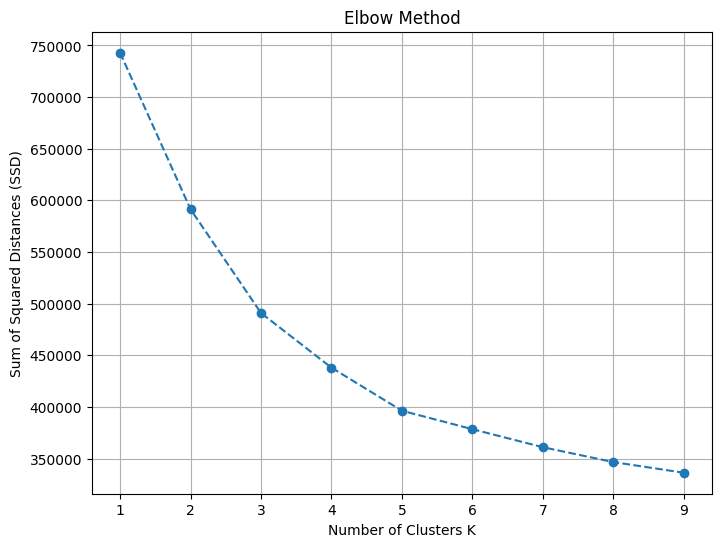

In [112]:
ssd = []
K_range = range(1,10)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    ssd.append(km.inertia_)  # Sum of Squared Distances

# Plot SSD vs K
plt.figure(figsize=(8,6))
plt.plot(K_range, ssd, 'o--')
plt.xlabel("Number of Clusters K")
plt.ylabel("Sum of Squared Distances (SSD)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

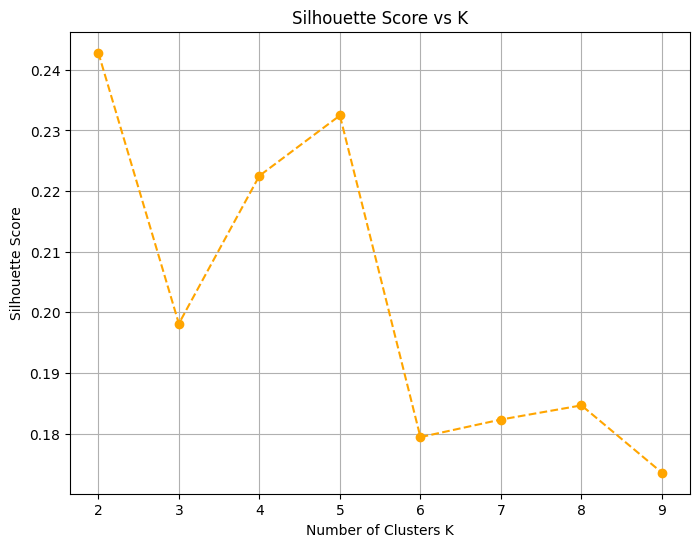

In [113]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    # fit K-Means and assign each point to a cluster
    labels = km.fit_predict(X)

    # average Silhouette Score for all points
    score = silhouette_score(X, labels)

    sil_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,6))
plt.plot(range(2,10), sil_scores, 'o--', color='orange')
plt.xlabel("Number of Clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.grid(True)
plt.show()